In [1]:
import pandas as pd

csv_base = "Absorbancia_hueco_VeMN22_5g.csv"
csv_limpio = "Absorbancia_hueco_VeMN22_5g_limpio.csv"

# Lee el archivo .csv completo
with open(csv_base, 'r') as f:
    lineas = f.readlines()

# Detectar línea de encabezado real (donde están los datos)
for i, linea in enumerate(lineas):
    if "nm" in linea and "A" in linea:
        inicio_datos = i + 1
        break

# Extrae los datos desde ahí
datos = [linea.strip().split(',') for linea in lineas[inicio_datos:] if linea.strip()]

# Crear el DataFrame a usar 
df = pd.DataFrame(datos, columns=["nm", "A"])

# Convierte las columnas a int o float (XXX.XXX se vuelven NaN (not a number) automáticamente)
df["nm"] = pd.to_numeric(df["nm"], errors='coerce')
df["A"] = pd.to_numeric(df["A"], errors='coerce')

# se guarda como nuevo CSV limpio (NO se eliminan NaN)
df.to_csv(csv_limpio, index=False)
print(f"Archivo limpio creado como: {csv_limpio}")

FileNotFoundError: [Errno 2] No such file or directory: 'Absorbancia_hueco_VeMN22_5g.csv'

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

carpeta = Path(".")  # ya estás en Cafeina_calibración

def limpiar_csv(archivo: Path):
    # Lee el CSV intentando inferir el separador y saltando líneas en blanco
    df = pd.read_csv(
        archivo,
        sep=None, engine="python",           # infiere delimitador: , ; \t
        skip_blank_lines=True
    )

    # Asegura 2 columnas y nómbralas nm, A (si hay más, toma las 2 primeras)
    if df.shape[1] >= 2:
        df = df.iloc[:, :2]
    else:
        raise ValueError(f"{archivo.name}: no encontré 2 columnas.")

    df.columns = ["nm", "A"]

    # Normaliza decimales con coma -> punto solo en strings
    for col in ["nm", "A"]:
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)

    # Convierte a numérico: lo no numérico -> NaN
    df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
    df["A"]  = pd.to_numeric(df["A"],  errors="coerce")

    # --- LIMPIEZAS CLAVE ---
    # 1) Quita filas donde nm no existe (son encabezados/ruido tipo ",84303.0" o vacías)
    df = df[~df["nm"].isna()].copy()

    # 2) (opcional pero útil) filtra nm a un rango físico razonable
    #    Ajusta si tu espectro cubre más:
    df = df[(df["nm"] >= 180) & (df["nm"] <= 1100)]

    # 3) Ordena por longitud de onda
    df = df.sort_values("nm", kind="mergesort").reset_index(drop=True)

    # 4) Deja A tal como quede: si falta dato, se mantiene NaN (lo que pediste)
    #    Si quieres forzar A negativa a NaN por seguridad, descomenta:
    # df.loc[df["A"] < 0, "A"] = np.nan

    # Guarda salida *_limpio.csv
    salida = archivo.with_name(archivo.stem + "_limpio.csv")
    df.to_csv(salida, index=False)
    print(f"✔ {archivo.name} → {salida.name}  ({len(df)} filas)")
    return salida

# Procesa todos los CSV de la carpeta (evita re-procesar los *_limpio.csv)
for f in sorted(carpeta.glob("*.csv")):
    if not f.stem.endswith("_limpio"):
        try:
            limpiar_csv(f)
        except Exception as e:
            print(f"⚠ {f.name}: {e}")



✔ 1ml.csv → 1ml_limpio.csv  (421 filas)
✔ 2ml.csv → 2ml_limpio.csv  (421 filas)
✔ 4ml.csv → 4ml_limpio.csv  (421 filas)
✔ 6ml.csv → 6ml_limpio.csv  (421 filas)
✔ 8ml.csv → 8ml_limpio.csv  (421 filas)
✔ error_no_tenia_tubo_de_cuarzo.csv → error_no_tenia_tubo_de_cuarzo_limpio.csv  (421 filas)


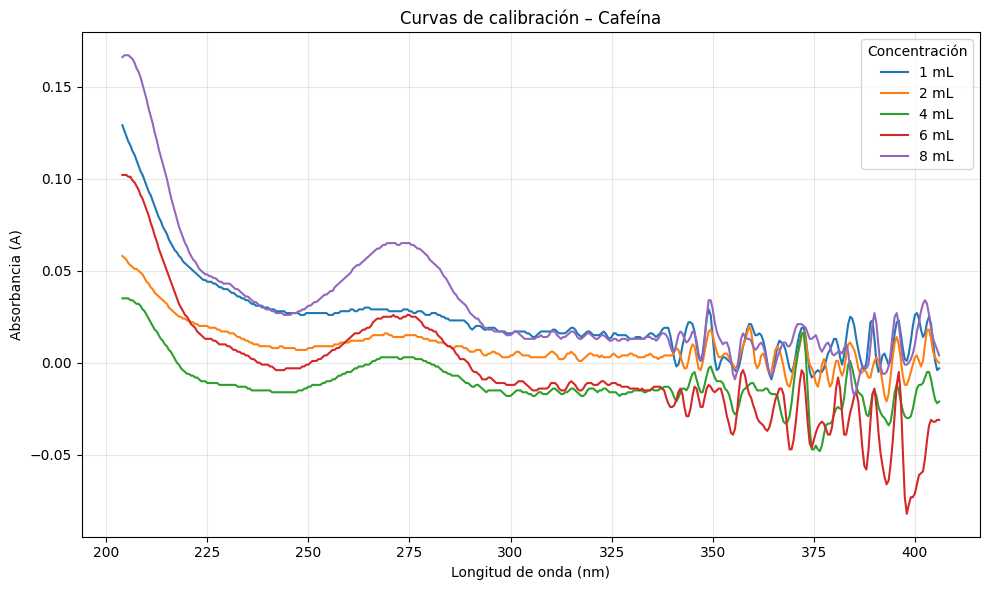

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# === Configuración ===
carpeta = Path(".")   # carpeta actual, ajusta si es otra
patron  = "*ml_limpio.csv"   # archivos a graficar

# === Leer y graficar ===
plt.figure(figsize=(10,6))

for f in sorted(carpeta.glob(patron)):
    # Extrae etiqueta (mL) del nombre de archivo: 1ml_limpio.csv -> "1 mL"
    etiqueta = re.search(r"(\d+)\s*ml", f.stem, re.IGNORECASE)
    label = f"{etiqueta.group(1)} mL" if etiqueta else f.stem
    
    df = pd.read_csv(f)
    plt.plot(df["nm"], df["A"], label=label)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Absorbancia (A)")
plt.title("Curvas de calibración – Cafeína")
plt.legend(title="Concentración")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
